In [5]:
from __future__ import annotations

import math
import random
import time
from dataclasses import dataclass

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from crackmnist.dataset import CrackMNIST

In [6]:
# ============================================================
# 1. CONFIG
# ============================================================

@dataclass
class Config:
    pixels: int = 128                # 28, 64 or 128
    size: str = "S"
    batch_size: int = 64             # reduce to 32 for 128 if needed
    epochs: int = 20
    lr: float = 3e-4
    weight_decay: float = 1e-4

    # Heatmap target. Sigma is expressed in pixels of the output heatmap.
    heatmap_sigma: float = 1.5
    heatmap_stride: int = 2          # output heatmap is H/2 x W/2

    # Loss weights
    heatmap_loss_weight: float = 1.0
    coord_loss_weight: float = 0.5

    # Physics feature
    use_physics: bool = False
    lambda_lame: float = 1.0         # replace with material lambda if known
    mu_lame: float = 1.0             # replace with material mu if known

    # Performance
    num_workers: int = 0             # cached tensors make workers unnecessary
    pin_memory: bool = True
    amp: bool = True
    channels_last: bool = True

    # Training control
    patience: int = 7
    seed: int = 42


CFG = Config()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True
    torch.set_float32_matmul_precision("high")

print(f"PyTorch: {torch.__version__}")
print(f"Device:  {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU:     {torch.cuda.get_device_name(0)}")


PyTorch: 2.9.1+cu130
Device:  cuda
GPU:     NVIDIA GeForce RTX 5070


In [7]:
# ============================================================
# 2. REPRODUCIBILITY
# ============================================================

def seed_everything(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


seed_everything(CFG.seed)


In [8]:
# ============================================================
# 3. DATA: LOAD ONCE, THEN TRAIN FROM RAM
# ============================================================

class CachedCrackDataset(Dataset):
    """
    Loads one CrackMNIST split into RAM.

    This is intentional: the original notebook repeatedly accesses the HDF5
    dataset and converts NumPy -> Tensor inside __getitem__, which can become
    the dominant cost for 64/128 px.
    """

    def __init__(
        self,
        split: str,
        pixels: int,
        size: str,
        mean: torch.Tensor | None = None,
        std: torch.Tensor | None = None,
    ):
        base = CrackMNIST(
            split=split,
            pixels=pixels,
            size=size,
            task="crack_tip_segmentation",
        )

        images = []
        coords = []

        print(f"Loading {split}: {len(base)} samples into RAM...")

        for i in range(len(base)):
            image, mask = base[i]

            image = np.asarray(image, dtype=np.float32)
            mask = np.asarray(mask)

            if image.ndim == 2:
                image = image[None, ...]

            # Expected CrackMNIST format: [2, H, W]
            if image.shape[0] != 2:
                raise ValueError(f"Expected 2 displacement channels, got {image.shape}")

            positions = np.argwhere(mask > 0)

            if len(positions) == 0:
                # Should not happen for valid crack-tip segmentation samples.
                y, x = 0, 0
            else:
                # The original notebook uses the first positive pixel.
                y, x = positions[0]

            images.append(image)
            coords.append((x, y))

        self.images = torch.from_numpy(np.stack(images, axis=0))
        self.coords = torch.tensor(coords, dtype=torch.float32)

        # Global train statistics are passed to val/test.
        if mean is None or std is None:
            mean = self.images.mean(dim=(0, 2, 3))
            std = self.images.std(dim=(0, 2, 3)).clamp_min(1e-6)

        self.mean = mean.float()
        self.std = std.float()

        self.images.sub_(
            self.mean[None, :, None, None]
        ).div_(
            self.std[None, :, None, None]
        )

        print(
            f"  images={tuple(self.images.shape)}, "
            f"RAM≈{self.images.numel() * 4 / 1024**3:.2f} GB"
        )

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        return self.images[idx], self.coords[idx]


def make_datasets(cfg: Config):
    train = CachedCrackDataset("train", cfg.pixels, cfg.size)
    val = CachedCrackDataset(
        "val", cfg.pixels, cfg.size,
        mean=train.mean, std=train.std
    )
    test = CachedCrackDataset(
        "test", cfg.pixels, cfg.size,
        mean=train.mean, std=train.std
    )
    return train, val, test


train_ds, val_ds, test_ds = make_datasets(CFG)

loader_kwargs = dict(
    batch_size=CFG.batch_size,
    pin_memory=CFG.pin_memory and DEVICE.type == "cuda",
    num_workers=CFG.num_workers,
)

train_loader = DataLoader(train_ds, shuffle=True, drop_last=False, **loader_kwargs)
val_loader = DataLoader(val_ds, shuffle=False, **loader_kwargs)
test_loader = DataLoader(test_ds, shuffle=False, **loader_kwargs)

Loading train: 10048 samples into RAM...
  images=(10048, 2, 128, 128), RAM≈1.23 GB
Loading val: 5944 samples into RAM...
  images=(5944, 2, 128, 128), RAM≈0.73 GB
Loading test: 5944 samples into RAM...
  images=(5944, 2, 128, 128), RAM≈0.73 GB


In [9]:
# ============================================================
# 4. OPTIONAL PHYSICS FEATURE
# ============================================================

class NavierCauchyResidual(nn.Module):
    """
    Fixed finite-difference approximation of the isotropic
    Navier-Cauchy equilibrium residual:

        mu * Laplacian(u)
        + (lambda + mu) * grad(div(u))

    It is used as an INPUT FEATURE, not as a PINN loss.

    Important:
    - lambda and mu must be consistent with the spatial units of the fields.
    - If the displacement fields are normalized, the absolute physical
      meaning of the residual changes. Therefore this feature is best used
      only after checking the scaling.
    """

    def __init__(self, lam: float = 1.0, mu: float = 1.0):
        super().__init__()

        self.lam = lam
        self.mu = mu

        # Central differences. dx=dy=1 pixel here.
        dx = torch.tensor(
            [[0.0, 0.0, 0.0],
             [-0.5, 0.0, 0.5],
             [0.0, 0.0, 0.0]]
        ).view(1, 1, 3, 3)

        dy = torch.tensor(
            [[0.0, -0.5, 0.0],
             [0.0,  0.0, 0.0],
             [0.0,  0.5, 0.0]]
        ).view(1, 1, 3, 3)

        lap = torch.tensor(
            [[0.0, 1.0, 0.0],
             [1.0, -4.0, 1.0],
             [0.0, 1.0, 0.0]]
        ).view(1, 1, 3, 3)

        self.register_buffer("dx", dx)
        self.register_buffer("dy", dy)
        self.register_buffer("lap", lap)

    def forward(self, u):
        ux = u[:, 0:1]
        uy = u[:, 1:2]

        ux_x = F.conv2d(ux, self.dx, padding=1)
        ux_y = F.conv2d(ux, self.dy, padding=1)
        uy_x = F.conv2d(uy, self.dx, padding=1)
        uy_y = F.conv2d(uy, self.dy, padding=1)

        div_u = ux_x + uy_y

        div_x = F.conv2d(div_u, self.dx, padding=1)
        div_y = F.conv2d(div_u, self.dy, padding=1)

        lap_ux = F.conv2d(ux, self.lap, padding=1)
        lap_uy = F.conv2d(uy, self.lap, padding=1)

        rx = self.mu * lap_ux + (self.lam + self.mu) * div_x
        ry = self.mu * lap_uy + (self.lam + self.mu) * div_y

        residual = torch.sqrt(rx.square() + ry.square() + 1e-8)

        # Per-image normalization prevents the channel from dominating
        # because of arbitrary displacement scale.
        flat = residual.flatten(1)
        residual = (residual - flat.mean(1)[:, None, None, None]) / (
            flat.std(1)[:, None, None, None] + 1e-6
        )

        return residual


physics = NavierCauchyResidual(
    CFG.lambda_lame,
    CFG.mu_lame
).to(DEVICE) if CFG.use_physics else None

In [10]:
# ============================================================
# 5. TARGET HEATMAP
# ============================================================

def make_gaussian_heatmaps(
    coords: torch.Tensor,
    out_h: int,
    out_w: int,
    stride: int,
    sigma: float,
    device: torch.device,
):
    """
    Creates one Gaussian keypoint heatmap per image.

    coords are [x, y] in original pixel coordinates.
    """
    coords_small = coords.to(device) / stride

    y = torch.arange(out_h, device=device, dtype=torch.float32)[None, :, None]
    x = torch.arange(out_w, device=device, dtype=torch.float32)[None, None, :]

    cx = coords_small[:, 0, None, None]
    cy = coords_small[:, 1, None, None]

    heatmap = torch.exp(
        -((x - cx).square() + (y - cy).square()) /
        (2.0 * sigma * sigma)
    )

    return heatmap.unsqueeze(1)

In [11]:
# ============================================================
# 6. MODEL
# ============================================================

class ConvBlock(nn.Module):
    def __init__(self, cin, cout):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(cin, cout, 3, padding=1, bias=False),
            nn.GroupNorm(8, cout),
            nn.SiLU(inplace=True),

            nn.Conv2d(cout, cout, 3, padding=1, bias=False),
            nn.GroupNorm(8, cout),
            nn.SiLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class SmallUNet(nn.Module):
    """
    Resolution-independent encoder/decoder.

    Downsampling is important here: unlike the original 3-convolution model,
    the network obtains a much larger receptive field as the image becomes
    64x64 or 128x128.
    """

    def __init__(self, in_channels=2, base=24):
        super().__init__()

        self.enc1 = ConvBlock(in_channels, base)
        self.enc2 = ConvBlock(base, base * 2)
        self.enc3 = ConvBlock(base * 2, base * 4)
        self.bottleneck = ConvBlock(base * 4, base * 6)

        self.pool = nn.MaxPool2d(2)

        self.dec3 = ConvBlock(base * 6 + base * 4, base * 4)
        self.dec2 = ConvBlock(base * 4 + base * 2, base * 2)
        self.dec1 = ConvBlock(base * 2 + base, base)

        # Predict at H/2 x W/2. This cuts output cost by 4.
        self.head = nn.Conv2d(base, 1, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)                 # H
        e2 = self.enc2(self.pool(e1))     # H/2
        e3 = self.enc3(self.pool(e2))     # H/4
        b = self.bottleneck(self.pool(e3))# H/8

        d3 = F.interpolate(
            b, size=e3.shape[-2:], mode="bilinear", align_corners=False
        )
        d3 = self.dec3(torch.cat([d3, e3], dim=1))

        d2 = F.interpolate(
            d3, size=e2.shape[-2:], mode="bilinear", align_corners=False
        )
        d2 = self.dec2(torch.cat([d2, e2], dim=1))

        d1 = F.interpolate(
            d2, size=e1.shape[-2:], mode="bilinear", align_corners=False
        )
        d1 = self.dec1(torch.cat([d1, e1], dim=1))

        # H -> H/2
        out = F.avg_pool2d(d1, kernel_size=2, stride=2)
        return self.head(out)


IN_CHANNELS = 3 if CFG.use_physics else 2
model = SmallUNet(in_channels=IN_CHANNELS).to(DEVICE)

if CFG.channels_last and DEVICE.type == "cuda":
    model = model.to(memory_format=torch.channels_last)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=CFG.lr,
    weight_decay=CFG.weight_decay,
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=20,
)

scaler = torch.amp.GradScaler(
    "cuda",
    enabled=CFG.amp and DEVICE.type == "cuda"
)

print(model)
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")


SmallUNet(
  (enc1): ConvBlock(
    (block): Sequential(
      (0): Conv2d(2, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): GroupNorm(8, 24, eps=1e-05, affine=True)
      (2): SiLU(inplace=True)
      (3): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): GroupNorm(8, 24, eps=1e-05, affine=True)
      (5): SiLU(inplace=True)
    )
  )
  (enc2): ConvBlock(
    (block): Sequential(
      (0): Conv2d(24, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): GroupNorm(8, 48, eps=1e-05, affine=True)
      (2): SiLU(inplace=True)
      (3): Conv2d(48, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): GroupNorm(8, 48, eps=1e-05, affine=True)
      (5): SiLU(inplace=True)
    )
  )
  (enc3): ConvBlock(
    (block): Sequential(
      (0): Conv2d(48, 96, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): GroupNorm(8, 96, eps=1e-05, affine=True)
      (

In [12]:
# ============================================================
# 7. SOFT-ARGMAX
# ============================================================

def soft_argmax_2d(logits: torch.Tensor, stride: int):
    """
    Differentiable coordinate extraction.

    Returns x,y in original image pixel coordinates.
    """
    b, _, h, w = logits.shape

    prob = torch.softmax(logits.flatten(1), dim=1).view(b, h, w)

    xs = torch.arange(w, device=logits.device, dtype=logits.dtype)
    ys = torch.arange(h, device=logits.device, dtype=logits.dtype)

    px = prob.sum(dim=1)
    py = prob.sum(dim=2)

    x = (px * xs[None, :]).sum(dim=1) * stride
    y = (py * ys[None, :]).sum(dim=1) * stride

    return torch.stack([x, y], dim=1)


In [13]:
# ============================================================
# 8. LOSSES + METRICS
# ============================================================

def coordinate_loss(pred_xy, true_xy, pixels):
    # Normalize coordinates so 28/64/128 have comparable scale.
    scale = float(max(pixels - 1, 1))
    return F.smooth_l1_loss(pred_xy / scale, true_xy / scale)


def batch_distance(pred_xy, true_xy):
    return torch.linalg.vector_norm(pred_xy - true_xy, dim=1)


In [14]:
# ============================================================
# 9. FORWARD WITH OPTIONAL PHYSICS CHANNEL
# ============================================================

def prepare_input(images):
    if CFG.use_physics:
        with torch.no_grad():
            phys = physics(images)
        images = torch.cat([images, phys], dim=1)

    if CFG.channels_last and DEVICE.type == "cuda":
        images = images.contiguous(memory_format=torch.channels_last)

    return images


In [15]:
# ============================================================
# 10. TRAIN / VALIDATION
# ============================================================

def train_one_epoch():
    model.train()

    total = 0.0
    n = 0

    for images, coords in train_loader:
        images = images.to(
            DEVICE,
            non_blocking=True,
        )
        coords = coords.to(
            DEVICE,
            non_blocking=True,
        )

        images = prepare_input(images)

        optimizer.zero_grad(set_to_none=True)

        with torch.autocast(
            device_type=DEVICE.type,
            dtype=torch.float16,
            enabled=CFG.amp and DEVICE.type == "cuda",
        ):
            logits = model(images)

            _, _, h, w = logits.shape

            target = make_gaussian_heatmaps(
                coords,
                h,
                w,
                CFG.heatmap_stride,
                CFG.heatmap_sigma,
                DEVICE,
            )

            heat_loss = F.mse_loss(
                torch.sigmoid(logits),
                target,
            )

            pred_xy = soft_argmax_2d(
                logits.float(),
                CFG.heatmap_stride,
            )

            coord_loss = coordinate_loss(
                pred_xy,
                coords,
                CFG.pixels,
            )

            loss = (
                CFG.heatmap_loss_weight * heat_loss
                + CFG.coord_loss_weight * coord_loss
            )

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()

        total += loss.item() * images.size(0)
        n += images.size(0)

    return total / n


@torch.no_grad()
def evaluate(loader):
    model.eval()

    total_loss = 0.0
    total_dist = 0.0
    n = 0

    all_distances = []

    for images, coords in loader:
        images = images.to(DEVICE, non_blocking=True)
        coords = coords.to(DEVICE, non_blocking=True)

        images = prepare_input(images)

        with torch.autocast(
            device_type=DEVICE.type,
            dtype=torch.float16,
            enabled=CFG.amp and DEVICE.type == "cuda",
        ):
            logits = model(images)

            _, _, h, w = logits.shape

            target = make_gaussian_heatmaps(
                coords,
                h,
                w,
                CFG.heatmap_stride,
                CFG.heatmap_sigma,
                DEVICE,
            )

            heat_loss = F.mse_loss(
                torch.sigmoid(logits),
                target,
            )

            pred_xy = soft_argmax_2d(
                logits.float(),
                CFG.heatmap_stride,
            )

            coord_loss = coordinate_loss(
                pred_xy,
                coords,
                CFG.pixels,
            )

            loss = (
                CFG.heatmap_loss_weight * heat_loss
                + CFG.coord_loss_weight * coord_loss
            )

        dist = batch_distance(pred_xy, coords)

        total_loss += loss.item() * images.size(0)
        total_dist += dist.sum().item()
        n += images.size(0)

        all_distances.append(dist.cpu())

    distances = torch.cat(all_distances)

    return (
        total_loss / n,
        total_dist / n,
        distances,
    )



In [16]:
# ============================================================
# 11. TRAINING LOOP
# ============================================================

best_val = float("inf")
best_state = None
bad_epochs = 0

history = {
    "train_loss": [],
    "val_loss": [],
    "val_dist": [],
}

print("\n" + "=" * 70)
print("TRAINING")
print("=" * 70)

for epoch in range(1, CFG.epochs + 1):
    t0 = time.perf_counter()

    train_loss = train_one_epoch()
    val_loss, val_dist, val_dists = evaluate(val_loader)

    scheduler.step(val_dist)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_dist"].append(val_dist)

    elapsed = time.perf_counter() - t0
    lr = optimizer.param_groups[0]["lr"]

    print(
        f"Epoch {epoch:02d}/{CFG.epochs} | "
        f"train={train_loss:.4f} | "
        f"val={val_loss:.4f} | "
        f"dist={val_dist:.2f}px | "
        f"≤1px={100*(val_dists<=1).float().mean():.1f}% | "
        f"≤2px={100*(val_dists<=2).float().mean():.1f}% | "
        f"lr={lr:.2e} | "
        f"time={elapsed:.1f}s"
    )

    if val_dist < best_val:
        best_val = val_dist
        best_state = {
            k: v.detach().cpu().clone()
            for k, v in model.state_dict().items()
        }
        bad_epochs = 0
    else:
        bad_epochs += 1

    if bad_epochs >= CFG.patience:
        print("Early stopping.")
        break


# Restore best model
if best_state is not None:
    model.load_state_dict(best_state)

torch.save(
    {
        "model_state": model.state_dict(),
        "config": CFG.__dict__,
        "mean": train_ds.mean,
        "std": train_ds.std,
        "best_val_distance": best_val,
    },
    f"crack_tip_{CFG.pixels}px.pt",
)



TRAINING
Epoch 01/20 | train=0.0478 | val=0.0307 | dist=32.16px | ≤1px=0.1% | ≤2px=0.2% | lr=3.00e-04 | time=16.5s
Epoch 02/20 | train=0.0207 | val=0.0188 | dist=27.86px | ≤1px=0.1% | ≤2px=0.4% | lr=3.00e-04 | time=13.5s
Epoch 03/20 | train=0.0104 | val=0.0066 | dist=5.17px | ≤1px=13.3% | ≤2px=44.0% | lr=3.00e-04 | time=13.5s
Epoch 04/20 | train=0.0034 | val=0.0049 | dist=3.59px | ≤1px=38.7% | ≤2px=79.6% | lr=3.00e-04 | time=13.5s
Epoch 05/20 | train=0.0023 | val=0.0041 | dist=3.50px | ≤1px=40.0% | ≤2px=81.7% | lr=3.00e-04 | time=13.5s
Epoch 06/20 | train=0.0016 | val=0.0038 | dist=3.34px | ≤1px=57.8% | ≤2px=88.1% | lr=3.00e-04 | time=13.5s
Epoch 07/20 | train=0.0013 | val=0.0036 | dist=4.10px | ≤1px=42.0% | ≤2px=82.0% | lr=3.00e-04 | time=13.5s
Epoch 08/20 | train=0.0009 | val=0.0033 | dist=3.96px | ≤1px=44.9% | ≤2px=85.0% | lr=3.00e-04 | time=13.5s
Epoch 09/20 | train=0.0007 | val=0.0031 | dist=3.80px | ≤1px=48.4% | ≤2px=88.5% | lr=3.00e-04 | time=13.5s
Epoch 10/20 | train=0.0006 | 

In [17]:
# ============================================================
# 12. FINAL TEST
# ============================================================

test_loss, test_dist, test_dists = evaluate(test_loader)

print("\n" + "=" * 70)
print("TEST")
print("=" * 70)
print(f"Mean distance:   {test_dist:.3f} px")
print(f"Median distance: {test_dists.median():.3f} px")
print(f"≤ 1 px:          {100*(test_dists<=1).float().mean():.2f}%")
print(f"≤ 2 px:          {100*(test_dists<=2).float().mean():.2f}%")
print(f"≤ 4 px:          {100*(test_dists<=4).float().mean():.2f}%")
print(f"≤ 8 px:          {100*(test_dists<=8).float().mean():.2f}%")




TEST
Mean distance:   1.933 px
Median distance: 1.097 px
≤ 1 px:          38.90%
≤ 2 px:          81.95%
≤ 4 px:          96.79%
≤ 8 px:          98.15%


In [18]:
# ============================================================
# 13. VISUALIZATION
# ============================================================

@torch.no_grad()
def plot_prediction(idx: int, dataset: Dataset):
    import matplotlib.pyplot as plt

    model.eval()

    image, true_xy = dataset[idx]
    x = image.unsqueeze(0).to(DEVICE)
    x = prepare_input(x)

    logits = model(x)
    pred_xy = soft_argmax_2d(
        logits.float(),
        CFG.heatmap_stride,
    )[0].cpu().numpy()

    true_xy = true_xy.numpy()
    ux = image[0].numpy()
    uy = image[1].numpy()

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    for ax, field, title in zip(
        axes,
        [ux, uy],
        [r"$u_x$", r"$u_y$"],
    ):
        im = ax.imshow(field, origin="upper")
        ax.scatter(
            pred_xy[0], pred_xy[1],
            s=120, marker="x",
            linewidths=2,
            label="Predicción",
        )
        ax.scatter(
            true_xy[0], true_xy[1],
            s=120,
            facecolors="none",
            edgecolors="lime",
            linewidths=2,
            label="Real",
        )
        ax.set_title(title)
        ax.legend()
        plt.colorbar(im, ax=ax)

    plt.tight_layout()
    plt.show()

    d = np.linalg.norm(pred_xy - true_xy)
    print(
        f"Real=({true_xy[0]:.2f}, {true_xy[1]:.2f}) | "
        f"Pred=({pred_xy[0]:.2f}, {pred_xy[1]:.2f}) | "
        f"Error={d:.2f}px"
    )


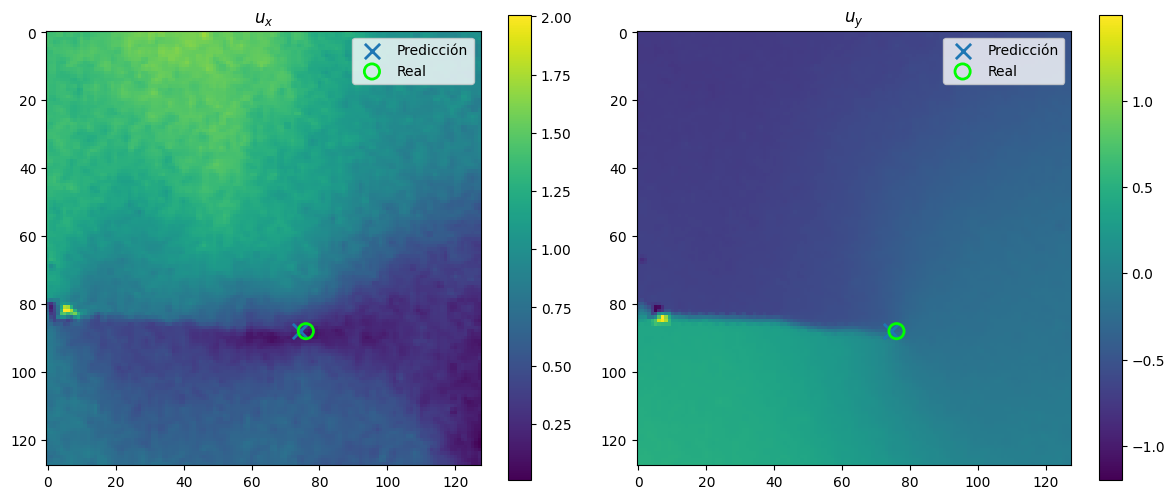

Real=(76.00, 88.00) | Pred=(74.31, 87.99) | Error=1.69px


In [19]:
plot_prediction(3504, val_ds)

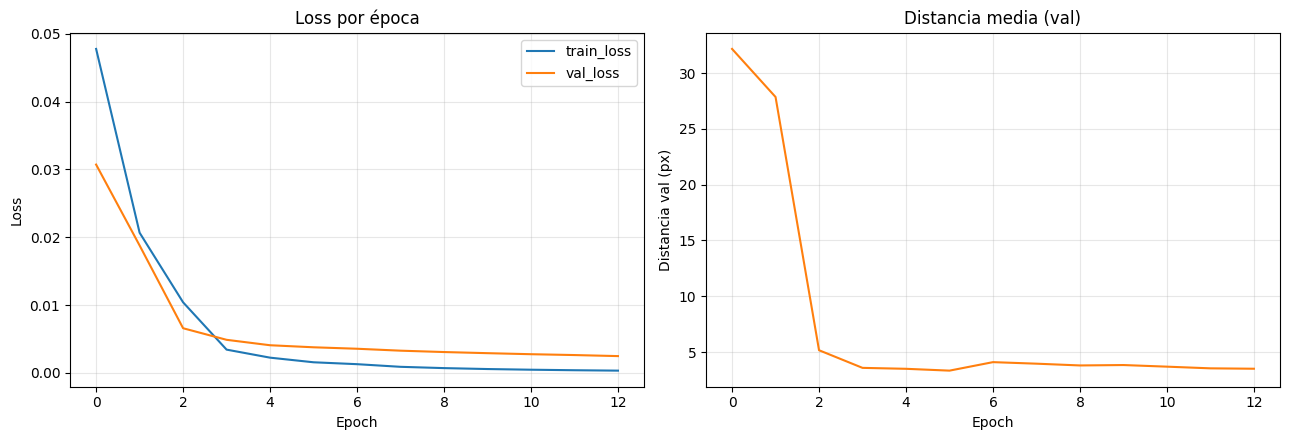

Mejor val_dist: 3.340 px (época 6)


In [20]:
# ============================================================
# 14. CURVAS DE ENTRENAMIENTO
# ============================================================
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(history["train_loss"], label="train_loss")
axes[0].plot(history["val_loss"], label="val_loss")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].set_title("Loss por época")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history["val_dist"], color="tab:orange")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Distancia val (px)")
axes[1].set_title("Distancia media (val)")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Mejor val_dist: {best_val:.3f} px (época {history['val_dist'].index(min(history['val_dist']))+1})")

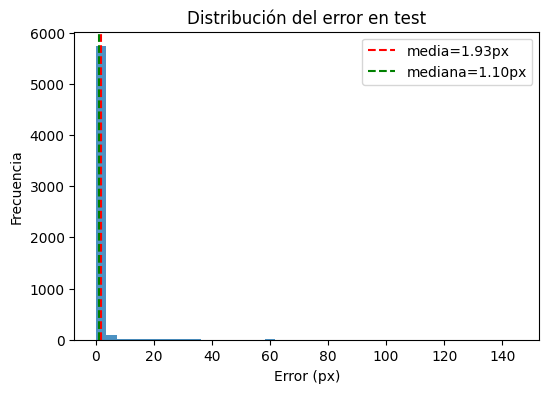

Peores 5 índices de test (mayor error): [5824, 5903, 5899, 5794, 5906]
Errores correspondientes: [145.48532 144.78256 133.89624 127.7287  126.69358]


In [21]:
# ============================================================
# 15. DISTRIBUCIÓN DE ERRORES EN TEST
# ============================================================
test_dists_np = test_dists.cpu().numpy()

plt.figure(figsize=(6,4))
plt.hist(test_dists_np, bins=40, color="tab:blue", alpha=0.8)
plt.axvline(test_dists_np.mean(), color="red", ls="--", label=f"media={test_dists_np.mean():.2f}px")
plt.axvline(np.median(test_dists_np), color="green", ls="--", label=f"mediana={np.median(test_dists_np):.2f}px")
plt.xlabel("Error (px)"); plt.ylabel("Frecuencia")
plt.title("Distribución del error en test")
plt.legend()
plt.show()

# Peores casos: útiles para ver si el error se concentra en muestras "raras"
worst_idx = np.argsort(test_dists_np)[::-1][:5]
print("Peores 5 índices de test (mayor error):", worst_idx.tolist())
print("Errores correspondientes:", test_dists_np[worst_idx])

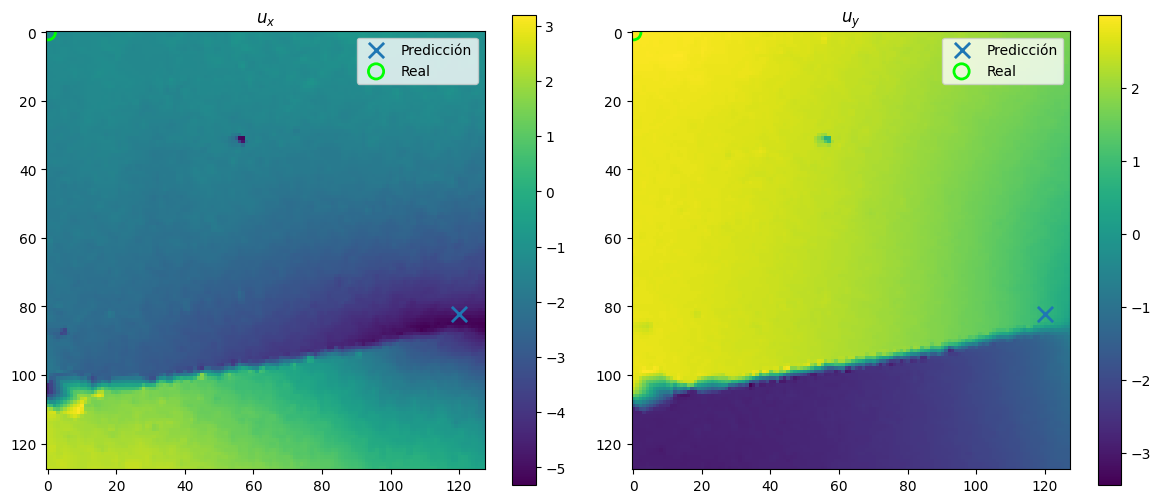

Real=(0.00, 0.00) | Pred=(120.01, 82.24) | Error=145.48px


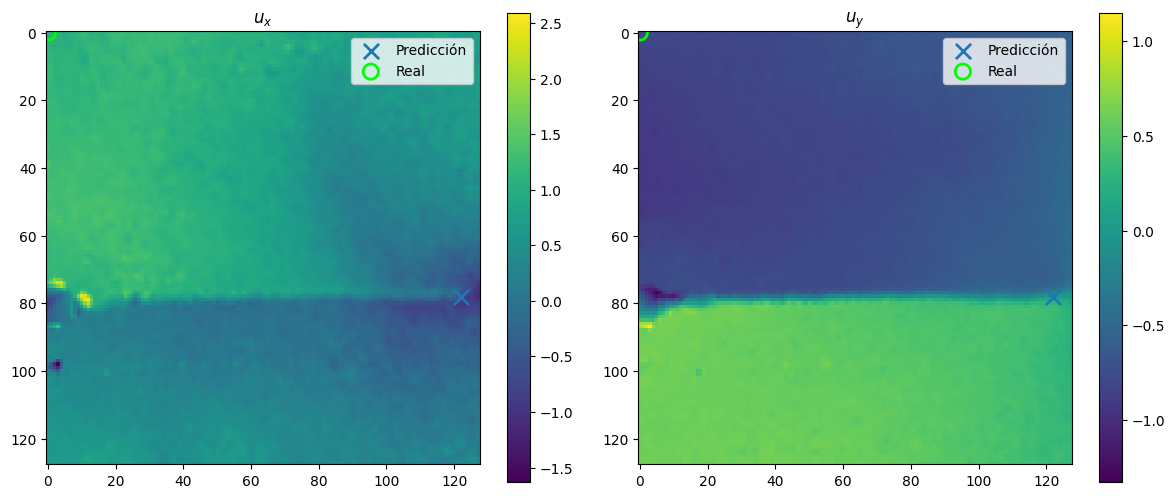

Real=(0.00, 0.00) | Pred=(121.98, 77.99) | Error=144.78px


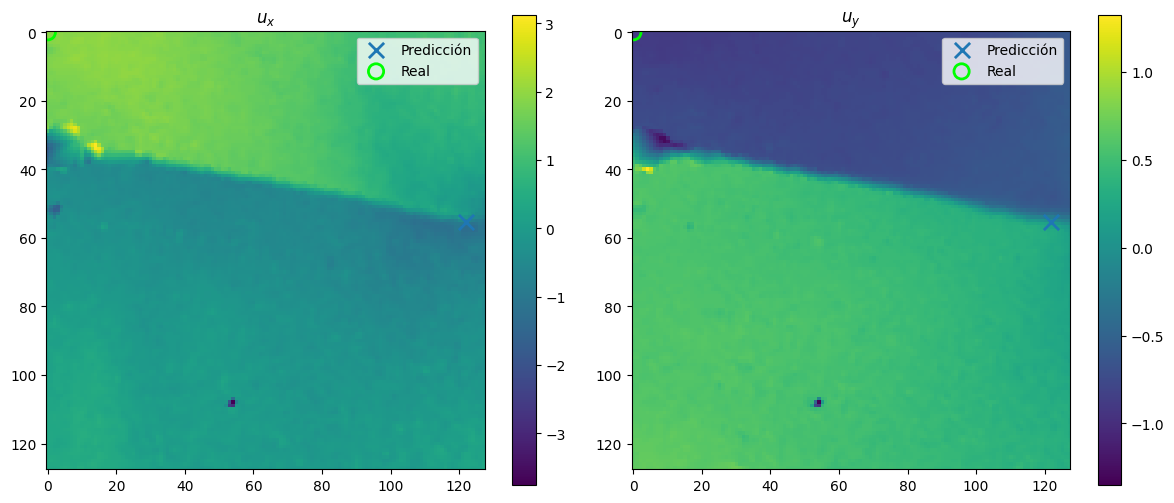

Real=(0.00, 0.00) | Pred=(121.91, 55.37) | Error=133.89px


In [22]:
# ============================================================
# 16. INSPECCIÓN VISUAL DE LOS PEORES CASOS
# ============================================================
for idx in worst_idx[:3]:
    plot_prediction(int(idx), test_ds)

In [23]:
# ============================================================
# 17. GUARDAR MODELO FINAL + HISTORIAL + MÉTRICAS DE TEST
# ============================================================
checkpoint = torch.load(f"crack_tip_{CFG.pixels}px.pt")

checkpoint["history"] = history
checkpoint["test_mean_dist"] = test_dist
checkpoint["test_median_dist"] = test_dists.median().item()

torch.save(checkpoint, f"crack_tip_{CFG.pixels}px.pt")
print(f"Checkpoint actualizado: crack_tip_{CFG.pixels}px.pt")

Checkpoint actualizado: crack_tip_128px.pt



INFORME ESTADÍSTICO DE CALIDAD EN TEST
            Métrica  Valor (px)
   Muestras Totales 5944.000000
  Error Medio (MAE)    1.932998
      Mediana (Q50)    1.097000
Desviación Estándar    6.305139
    IQR (Q75 - Q25)    0.801740
       Percentil 90    2.236004
       Percentil 95    3.078065
       Error Máximo  145.484421
               RMSE    6.594790
   Sesgo Medio en X    0.216692
   Sesgo Medio en Y   -0.056983


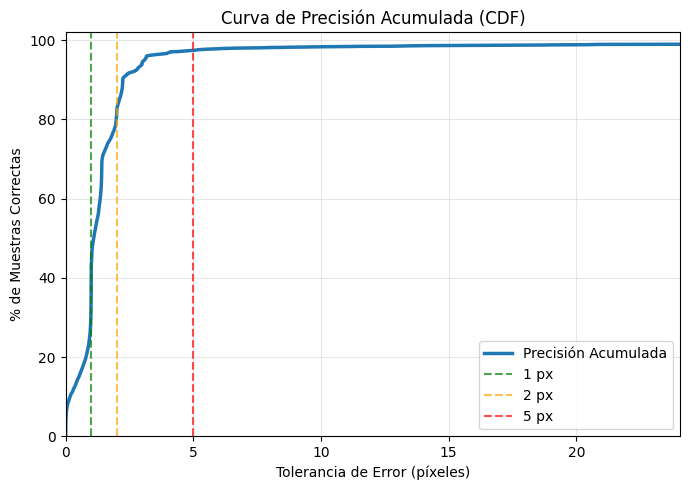

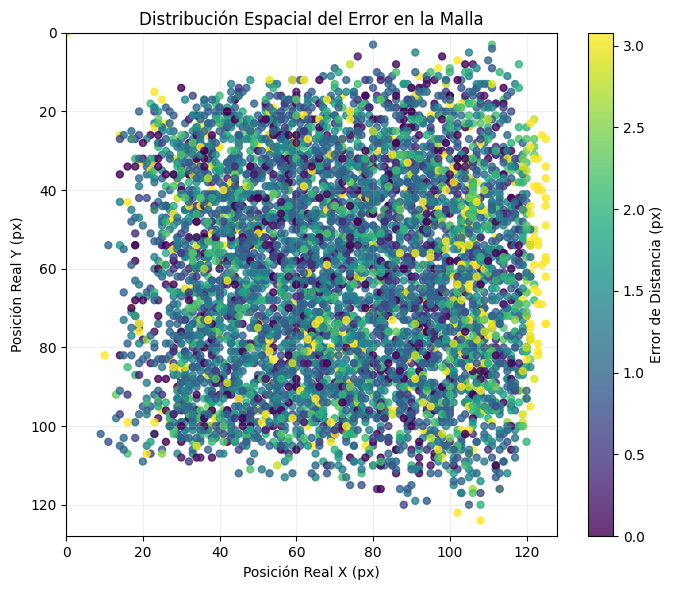

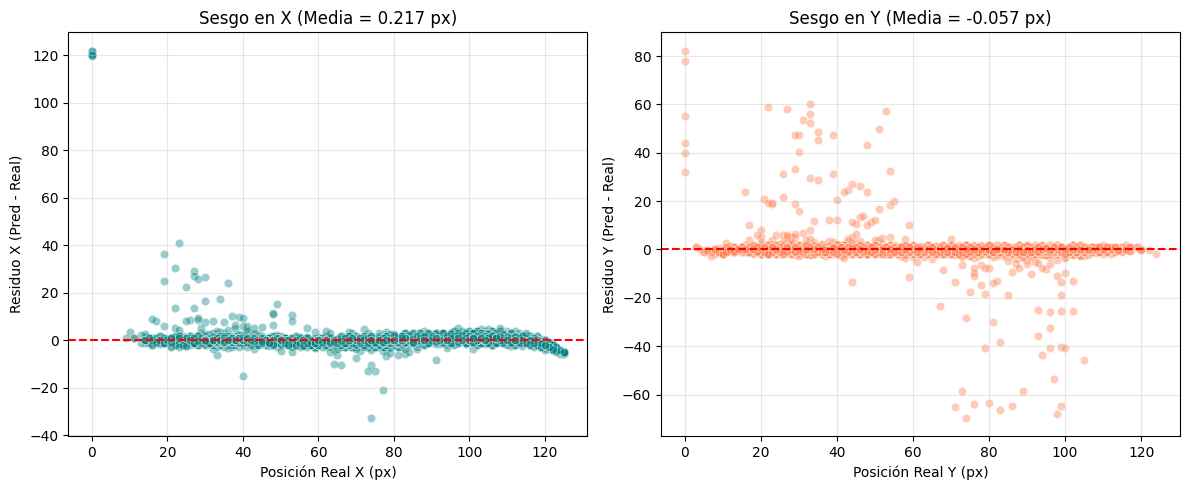

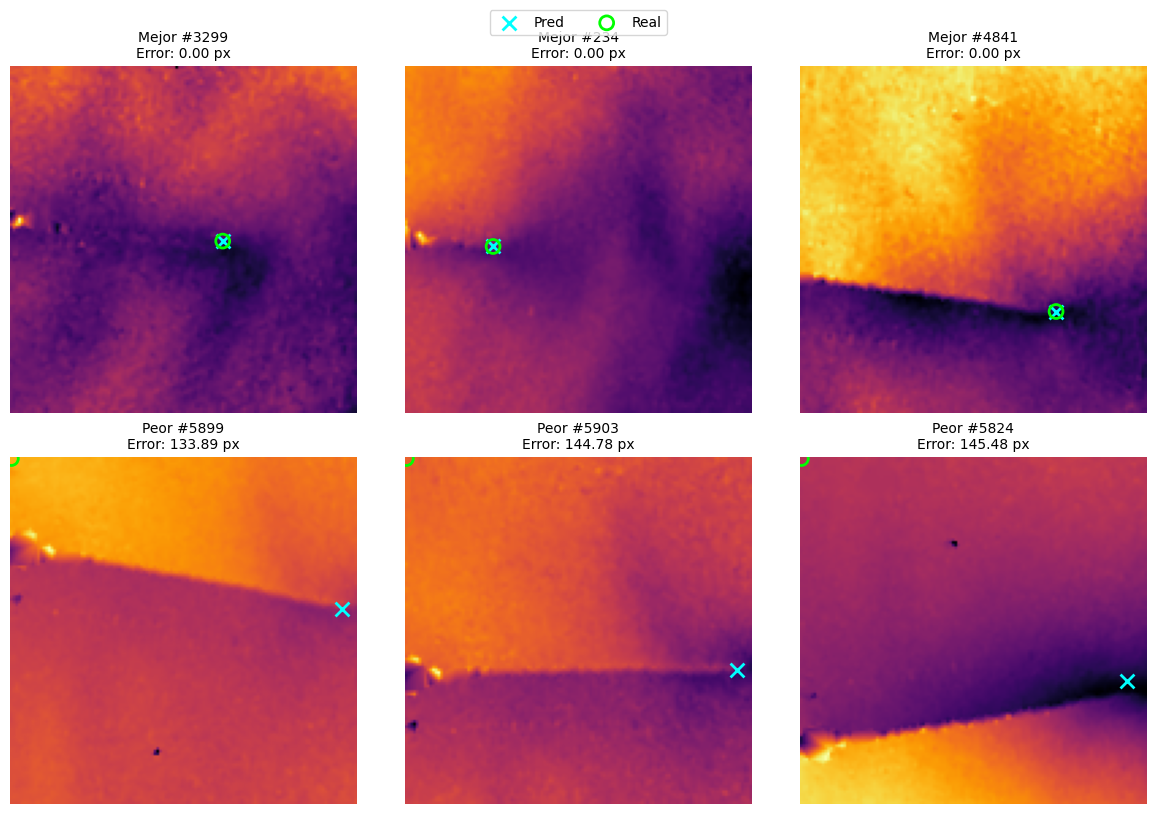

In [24]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Directory for saving figures
SAVE_DIR = "model_eval_plots"
os.makedirs(SAVE_DIR, exist_ok=True)

# ============================================================
# 1. RECOLECCIÓN DETALLADA DE PREDICCIONES
# ============================================================
@torch.no_grad()
def collect_test_predictions(model, loader):
    model.eval()
    all_preds, all_trues, all_dists = [], [], []

    for images, coords in loader:
        images_dev = images.to(DEVICE, non_blocking=True)
        images_dev = prepare_input(images_dev)
        
        logits = model(images_dev)
        pred_xy = soft_argmax_2d(logits.float(), CFG.heatmap_stride).cpu().numpy()
        true_xy = coords.numpy()
        
        dists = np.linalg.norm(pred_xy - true_xy, axis=1)
        
        all_preds.append(pred_xy)
        all_trues.append(true_xy)
        all_dists.append(dists)

    preds = np.vstack(all_preds)
    trues = np.vstack(all_trues)
    dists = np.concatenate(all_dists)
    
    return preds, trues, dists

preds, trues, dists = collect_test_predictions(model, test_loader)
err_x = preds[:, 0] - trues[:, 0]
err_y = preds[:, 1] - trues[:, 1]

# ============================================================
# 2. RESUMEN ESTADÍSTICO DE CALIDAD
# ============================================================
stats = {
    "Métrica": [
        "Muestras Totales", "Error Medio (MAE)", "Mediana (Q50)", 
        "Desviación Estándar", "IQR (Q75 - Q25)", "Percentil 90", 
        "Percentil 95", "Error Máximo", "RMSE",
        "Sesgo Medio en X", "Sesgo Medio en Y"
    ],
    "Valor (px)": [
        len(dists), np.mean(dists), np.median(dists),
        np.std(dists), np.percentile(dists, 75) - np.percentile(dists, 25),
        np.percentile(dists, 90), np.percentile(dists, 95), np.max(dists),
        np.sqrt(np.mean(dists**2)), np.mean(err_x), np.mean(err_y)
    ]
}

df_stats = pd.DataFrame(stats)
print("\n" + "=" * 50)
print("INFORME ESTADÍSTICO DE CALIDAD EN TEST")
print("=" * 50)
print(df_stats.to_string(index=False))
df_stats.to_csv(f"{SAVE_DIR}/metricas_estadisticas.csv", index=False)

# ============================================================
# 3. GRÁFICO 1: CURVA ACUMULADA DE PRECISIÓN (CDF)
# ============================================================
plt.figure(figsize=(7, 5))
sorted_dists = np.sort(dists)
cdf = np.arange(1, len(sorted_dists) + 1) / len(sorted_dists) * 100

plt.plot(sorted_dists, cdf, color="#1f77b4", lw=2.5, label="Precisión Acumulada")
plt.axvline(1.0, color="green", linestyle="--", alpha=0.7, label="1 px")
plt.axvline(2.0, color="orange", linestyle="--", alpha=0.7, label="2 px")
plt.axvline(5.0, color="red", linestyle="--", alpha=0.7, label="5 px")

plt.xlim(0, max(10, np.percentile(dists, 99)))
plt.ylim(0, 102)
plt.xlabel("Tolerancia de Error (píxeles)")
plt.ylabel("% de Muestras Correctas")
plt.title("Curva de Precisión Acumulada (CDF)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/01_curva_precision_acumulada.png", dpi=300)
plt.show()

# ============================================================
# 4. GRÁFICO 2: DISTRIBUCIÓN ESPACIAL DEL ERROR (HEATMAP 2D)
# ============================================================
plt.figure(figsize=(7, 6))
sc = plt.scatter(
    trues[:, 0], trues[:, 1], 
    c=dists, cmap="viridis", 
    s=25, alpha=0.8, vmin=0, vmax=np.percentile(dists, 95)
)
cbar = plt.colorbar(sc)
cbar.set_label("Error de Distancia (px)")
plt.gca().invert_yaxis()  # Origen en la esquina superior izquierda (formato imagen)
plt.xlim(0, CFG.pixels)
plt.ylim(CFG.pixels, 0)
plt.xlabel("Posición Real X (px)")
plt.ylabel("Posición Real Y (px)")
plt.title("Distribución Espacial del Error en la Malla")
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/02_mapa_error_espacial.png", dpi=300)
plt.show()

# ============================================================
# 5. GRÁFICO 3: ANÁLISIS DE RESIDUOS Y SESGO (X vs Y)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.scatterplot(x=trues[:, 0], y=err_x, ax=axes[0], alpha=0.4, color="teal")
axes[0].axhline(0, color="red", linestyle="--", lw=1.5)
axes[0].set_xlabel("Posición Real X (px)")
axes[0].set_ylabel("Residuo X (Pred - Real)")
axes[0].set_title(f"Sesgo en X (Media = {np.mean(err_x):.3f} px)")
axes[0].grid(True, alpha=0.3)

sns.scatterplot(x=trues[:, 1], y=err_y, ax=axes[1], alpha=0.4, color="coral")
axes[1].axhline(0, color="red", linestyle="--", lw=1.5)
axes[1].set_xlabel("Posición Real Y (px)")
axes[1].set_ylabel("Residuo Y (Pred - Real)")
axes[1].set_title(f"Sesgo en Y (Media = {np.mean(err_y):.3f} px)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/03_analisis_residuos_sesgo.png", dpi=300)
plt.show()

# ============================================================
# 6. GRÁFICO 4: GALERÍA COMPARATIVA (MEJORES VS PEORES)
# ============================================================
sorted_indices = np.argsort(dists)
best_ids = sorted_indices[:3]
worst_ids = sorted_indices[-3:]

fig, axes = plt.subplots(2, 3, figsize=(12, 8))

def draw_sample(ax, sample_idx, is_best=True):
    img, true_xy = test_ds[sample_idx]
    x_in = img.unsqueeze(0).to(DEVICE)
    x_in = prepare_input(x_in)
    
    with torch.no_grad():
        out_logits = model(x_in)
        p_xy = soft_argmax_2d(out_logits.float(), CFG.heatmap_stride)[0].cpu().numpy()
    
    t_xy = true_xy.numpy()
    err = np.linalg.norm(p_xy - t_xy)
    
    ax.imshow(img[0].numpy(), cmap="inferno")
    ax.scatter(p_xy[0], p_xy[1], color="cyan", marker="x", s=100, linewidths=2, label="Pred")
    ax.scatter(t_xy[0], t_xy[1], edgecolors="lime", facecolors="none", s=100, linewidths=2, label="Real")
    
    tag = "Mejor" if is_best else "Peor"
    ax.set_title(f"{tag} #{sample_idx}\nError: {err:.2f} px", fontsize=10)
    ax.axis("off")

for idx, b_id in enumerate(best_ids):
    draw_sample(axes[0, idx], b_id, is_best=True)

for idx, w_id in enumerate(worst_ids):
    draw_sample(axes[1, idx], w_id, is_best=False)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.02))
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/04_galeria_mejores_peores.png", dpi=300, bbox_inches="tight")
plt.show()